# Unsupervised Learning: More Density Clustering

In [2]:
import numpy as np 
import pandas as pd
from sklearn.cluster import DBSCAN, OPTICS
from sklearn.datasets import make_circles
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import seaborn as sns
import matplotlib.pyplot as plt

Learning objectives:
- Practice implementing density clustering
- Practice visualizing and evaluating performance
- Understand the subtle differences between different density clustering algorithms

Notes:
- Use `sklearn.datasets` as needed
- Put all import statements at the top of this notebook
- Use `sns.scatterplot` to plot the clusters (e.g. `hue=color_var`)

## Datasets

We'll work with two synthetic datasets to explore how density clustering handles different density scenarios:

1. **Dataset 1**: Noisy concentric circles with **even density** (uniformly distributed points)
2. **Dataset 2**: Clusters with **very uneven density** (dense, medium, and sparse clusters)

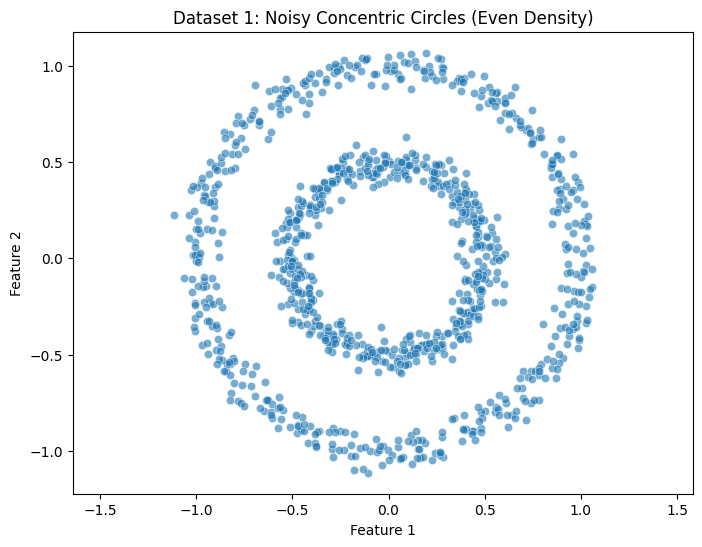

Dataset shape: (1000, 2)
Notice: Both circles have the same point density


In [3]:
# Dataset 1: Noisy concentric circles with even density
np.random.seed(42)
X_circles, y_circles = make_circles(n_samples=1000, factor=0.5, noise=0.05)

# Visualize the dataset
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_circles[:, 0], y=X_circles[:, 1], alpha=0.6)
plt.title('Dataset 1: Noisy Concentric Circles (Even Density)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.axis('equal')
plt.show()

print(f"Dataset shape: {X_circles.shape}")
print(f"Notice: Both circles have the same point density")

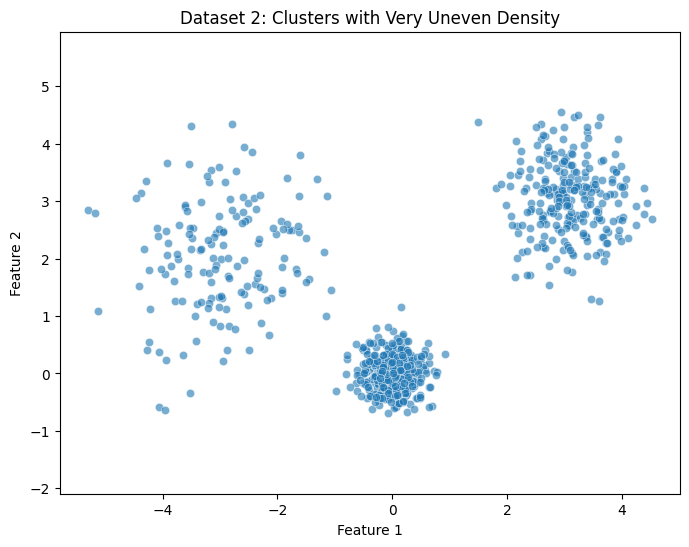

Dense cluster: 400 points, std=0.3
Medium cluster: 250 points, std=0.6
Sparse cluster: 150 points, std=0.9
Notice: Very different densities within the same dataset!


In [4]:
# Dataset 2: Clusters with very uneven density
# Create multiple blobs with very different standard deviations to simulate extreme varying densities
np.random.seed(42)

# Very dense cluster (very small std, many points)
X_dense = np.random.randn(400, 2) * 0.3 + np.array([0, 0])

# Medium density cluster
X_medium = np.random.randn(250, 2) * 0.6 + np.array([3, 3])

# Very sparse cluster (large std, fewer points)
X_sparse = np.random.randn(150, 2) * 0.9 + np.array([-3, 2])

# Combine all clusters
X_uneven = np.vstack([X_dense, X_medium, X_sparse])

# Visualize the dataset
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_uneven[:, 0], y=X_uneven[:, 1], alpha=0.6)
plt.title('Dataset 2: Clusters with Very Uneven Density')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.axis('equal')
plt.show()

print(f"Dense cluster: 400 points, std=0.3")
print(f"Medium cluster: 250 points, std=0.6")
print(f"Sparse cluster: 150 points, std=0.9")
print(f"Notice: Very different densities within the same dataset!")

----

## Part 1: DBSCAN Clustering

**Quick Parameter Guide:**
- `eps`: Maximum distance between two points to be considered neighbors
  - Too small → Everything becomes noise
  - Too large → Everything merges into one cluster
  - **Hint**: For Dataset 1 (circles), try values around 0.15-0.20
  - **Hint**: For Dataset 2 (uneven), you'll need to experiment more!
- `min_samples`: Minimum number of points to form a dense region
  - **Hint**: Start with 5

### Q: Use `sklearn`'s `DBSCAN` to cluster both datasets

Try different `eps` values to see what works best!

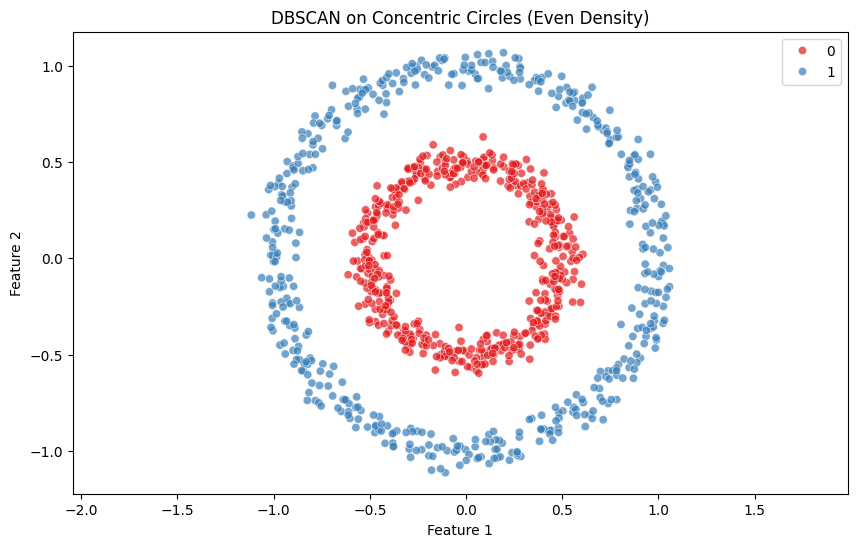

Number of clusters: 2
Number of noise points: 0


In [6]:
# DBSCAN on Dataset 1: Noisy Concentric Circles (Even Density)
# YOUR CODE HERE
dbscan_circles = DBSCAN(eps=0.20, min_samples=5)
labels_dbscan_circles = dbscan_circles.fit_predict(X_circles)

# Visualize clustering results
# YOUR CODE HERE
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_circles[:, 0], y=X_circles[:, 1], hue=labels_dbscan_circles, palette='Set1', alpha=0.7, legend='full')
plt.title('DBSCAN on Concentric Circles (Even Density)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.axis('equal')
plt.show()

# Print clustering statistics
# YOUR CODE HERE
n_clusters_circles = len(set(labels_dbscan_circles)) - (1 if -1 in labels_dbscan_circles else 0)
n_noise_circles = list(labels_dbscan_circles).count(-1)
print(f"Number of clusters: {n_clusters_circles}")
print(f"Number of noise points: {n_noise_circles}")

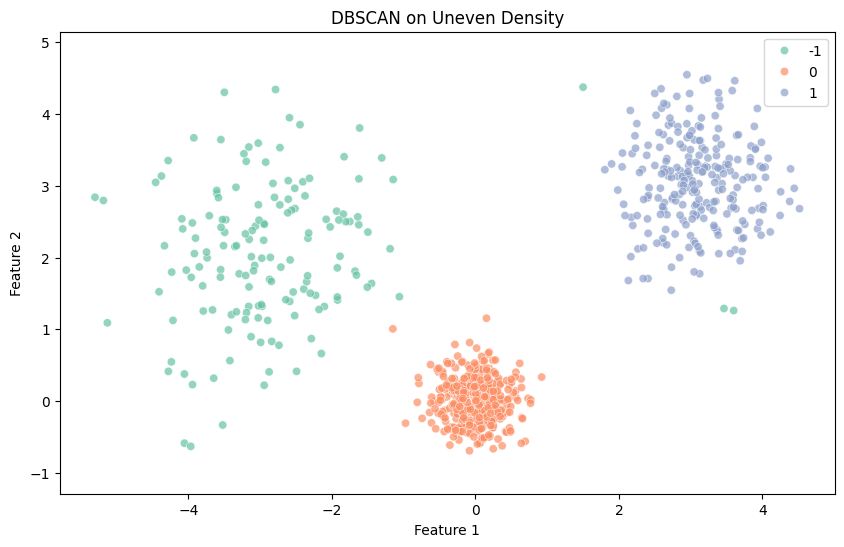

Number of clusters: 2
Number of noise points: 152


In [46]:
# DBSCAN on Dataset 2: Uneven Density Clusters
# YOUR CODE HERE
dbscan_uneven = DBSCAN(eps=0.90, min_samples= 90)
labels_dbscan_uneven = dbscan_uneven.fit_predict(X_uneven)

# Visualize clustering results
# YOUR CODE HERE
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_uneven[:, 0], y=X_uneven[:, 1], hue=labels_dbscan_uneven, palette='Set2', alpha=0.7, legend='full')
plt.title('DBSCAN on Uneven Density')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.axis('equal')
plt.show()

# Print clustering statistics
# YOUR CODE HERE
n_clusters_uneven = len(set(labels_dbscan_uneven)) - (1 if -1 in labels_dbscan_uneven else 0)
n_noise_uneven = list(labels_dbscan_uneven).count(-1)
print(f"Number of clusters: {n_clusters_uneven}")
print(f"Number of noise points: {n_noise_uneven}")

### Q: Compute quantitative evaluation metrics for DBSCAN

Use the clustering metrics we imported (`silhouette_score`, `davies_bouldin_score`, `calinski_harabasz_score`) to evaluate DBSCAN's performance on both datasets.

**Important:** Exclude noise points (label = -1) when computing these metrics.

In [47]:
# Evaluate DBSCAN on Dataset 1 (Even Density Circles)
# YOUR CODE HERE
# Filter out noise points first
mask_circles = labels_dbscan_circles != -1
# 
if mask_circles.sum() > 0 and len(set(labels_dbscan_circles[mask_circles])) > 1:
    silhouette_dbscan_circles = silhouette_score(X=X_circles[:, 0], labels=mask_circles)
    davies_bouldin_dbscan_circles = davies_bouldin_score(X=X_circles[:, 0], labels=mask_circles)
#     calinski_dbscan_circles = calinski_harabasz_score(     ,     )
#     
#     print("DBSCAN Performance on Dataset 1 (Even Density Circles):")
#     print(f"  Silhouette Score: {silhouette_dbscan_circles:.4f} (higher is better, range: -1 to 1)")
#     print(f"  Davies-Bouldin Index: {davies_bouldin_dbscan_circles:.4f} (lower is better)")
#     print(f"  Calinski-Harabasz Index: {calinski_dbscan_circles:.4f} (higher is better)")

# Evaluate DBSCAN on Dataset 2 (Uneven Density)
# YOUR CODE HERE
# mask_uneven = labels_dbscan_uneven != -1
# 
# if mask_uneven.sum() > 0 and len(set(labels_dbscan_uneven[mask_uneven])) > 1:
#     silhouette_dbscan_uneven = silhouette_score(     ,     )
#     davies_bouldin_dbscan_uneven = davies_bouldin_score(     ,     )
#     calinski_dbscan_uneven = calinski_harabasz_score(     ,     )
#     
#     print("\nDBSCAN Performance on Dataset 2 (Uneven Density):")
#     print(f"  Silhouette Score: {silhouette_dbscan_uneven:.4f}")
#     print(f"  Davies-Bouldin Index: {davies_bouldin_dbscan_uneven:.4f}")
#     print(f"  Calinski-Harabasz Index: {calinski_dbscan_uneven:.4f}")

ValueError: Expected 2D array, got 1D array instead:
array=[ 4.52592385e-01 -4.38026517e-01 -5.32224305e-01 -3.01401805e-01
  4.45602231e-01 -2.84527603e-01 -1.22755659e-02  4.63617169e-01
 -1.15778916e-01 -1.10616133e-01 -4.70559840e-01  5.64062537e-01
 -8.14012754e-02  4.37674617e-01  4.08347491e-01  6.95081940e-02
 -9.41735419e-01  9.48013984e-02 -5.39471510e-01 -6.38796243e-01
  3.64429290e-01 -5.52103798e-01 -1.94821778e-03  4.47125517e-01
 -9.30876202e-01 -9.06798685e-01  2.79665245e-01  5.56630915e-01
  1.45039375e-01  4.41336732e-01 -2.87116713e-01 -2.56633963e-01
 -2.77971111e-02  1.00845075e+00 -1.07332687e-01 -7.84963857e-01
 -3.61467296e-01  3.35471852e-01  1.71314857e-01  7.50025314e-01
 -6.23947874e-01  3.65606046e-01 -7.16047060e-01  6.00483708e-01
 -8.45743592e-01 -8.89440713e-01  3.31398676e-01  1.37026812e-01
  7.83815302e-01 -3.04928181e-01  2.62441044e-01  2.47894864e-02
 -9.50239470e-01  3.32460802e-01  9.07662180e-01  8.89820957e-01
  5.02158133e-02  9.58236391e-0

### Q: Based on the metrics above, how did DBSCAN perform on each dataset? 

Compare Dataset 1 (even density) vs Dataset 2 (uneven density). Which was easier for DBSCAN to cluster? Did you need to use different `eps` values for the two datasets?

### A:
YOUR ANSWER HERE

----

## Part 2: OPTICS Clustering

**OPTICS** (Ordering Points To Identify the Clustering Structure) is similar to DBSCAN but can handle clusters with varying densities better. Unlike DBSCAN which requires a fixed `eps` parameter, OPTICS creates a reachability plot that can identify clusters at different density levels.

**Key differences from DBSCAN:**
- Can find clusters of varying densities
- Uses `max_eps` instead of fixed `eps`
- More computationally expensive

**Resources:**
- [Wikipedia article](https://en.wikipedia.org/wiki/OPTICS_algorithm)
- [sklearn docs](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.OPTICS.html)

**Quick Parameter Guide:**
- `min_samples`: Same meaning as in DBSCAN (try 5)
- `xi`: Steepness threshold for cluster extraction (try 0.05)
  - Controls how OPTICS extracts clusters from the reachability plot
  - Lower values → more clusters, higher values → fewer clusters
- `min_cluster_size`: Minimum fraction of samples in a cluster (try 0.05)
  - Helps avoid tiny clusters

**Hint**: Using `xi` and `min_cluster_size` gives better results than just `max_eps`!

### Q: Use `sklearn`'s `OPTICS` to cluster both datasets

In [ ]:
# OPTICS on Dataset 1: Noisy Concentric Circles (Even Density)
# YOUR CODE HERE
# optics_circles = OPTICS(min_samples=    , xi=    , min_cluster_size=    )
# labels_optics_circles = optics_circles.fit_predict(     )

# Visualize clustering results
# YOUR CODE HERE
# plt.figure(figsize=(10, 6))
# sns.scatterplot(x=     , y=     , hue=     , palette='Set1', alpha=0.7, legend='full')
# plt.title('OPTICS on Concentric Circles (Even Density)')
# plt.xlabel('Feature 1')
# plt.ylabel('Feature 2')
# plt.axis('equal')
# plt.show()

# Print clustering statistics
# YOUR CODE HERE
# n_clusters_optics_circles = len(set(labels_optics_circles)) - (1 if -1 in labels_optics_circles else 0)
# n_noise_optics_circles = list(labels_optics_circles).count(-1)
# print(f"Number of clusters: {n_clusters_optics_circles}")
# print(f"Number of noise points: {n_noise_optics_circles}")

In [ ]:
# OPTICS on Dataset 2: Uneven Density Clusters
# YOUR CODE HERE
# optics_uneven = OPTICS(min_samples=    , xi=    , min_cluster_size=    )
# labels_optics_uneven = optics_uneven.fit_predict(     )

# Visualize clustering results
# YOUR CODE HERE
# plt.figure(figsize=(10, 6))
# sns.scatterplot(x=     , y=     , hue=     , palette='Set2', alpha=0.7, legend='full')
# plt.title('OPTICS on Uneven Density')
# plt.xlabel('Feature 1')
# plt.ylabel('Feature 2')
# plt.axis('equal')
# plt.show()

# Print clustering statistics
# YOUR CODE HERE
# n_clusters_optics_uneven = len(set(labels_optics_uneven)) - (1 if -1 in labels_optics_uneven else 0)
# n_noise_optics_uneven = list(labels_optics_uneven).count(-1)
# print(f"Number of clusters: {n_clusters_optics_uneven}")
# print(f"Number of noise points: {n_noise_optics_uneven}")

### Q: Compute quantitative evaluation metrics for OPTICS

Use the same metrics to evaluate OPTICS's performance on both datasets.

In [ ]:
# Evaluate OPTICS on Dataset 1 (Even Density Circles)
# YOUR CODE HERE
# mask_optics_circles = labels_optics_circles != -1
# 
# if mask_optics_circles.sum() > 0 and len(set(labels_optics_circles[mask_optics_circles])) > 1:
#     silhouette_optics_circles = silhouette_score(     ,     )
#     davies_bouldin_optics_circles = davies_bouldin_score(     ,     )
#     calinski_optics_circles = calinski_harabasz_score(     ,     )
#     
#     print("OPTICS Performance on Dataset 1 (Even Density Circles):")
#     print(f"  Silhouette Score: {silhouette_optics_circles:.4f}")
#     print(f"  Davies-Bouldin Index: {davies_bouldin_optics_circles:.4f}")
#     print(f"  Calinski-Harabasz Index: {calinski_optics_circles:.4f}")

# Evaluate OPTICS on Dataset 2 (Uneven Density)
# YOUR CODE HERE
# mask_optics_uneven = labels_optics_uneven != -1
# 
# if mask_optics_uneven.sum() > 0 and len(set(labels_optics_uneven[mask_optics_uneven])) > 1:
#     silhouette_optics_uneven = silhouette_score(     ,     )
#     davies_bouldin_optics_uneven = davies_bouldin_score(     ,     )
#     calinski_optics_uneven = calinski_harabasz_score(     ,     )
#     
#     print("\nOPTICS Performance on Dataset 2 (Uneven Density):")
#     print(f"  Silhouette Score: {silhouette_optics_uneven:.4f}")
#     print(f"  Davies-Bouldin Index: {davies_bouldin_optics_uneven:.4f}")
#     print(f"  Calinski-Harabasz Index: {calinski_optics_uneven:.4f}")

----

## Part 3: Comparing DBSCAN vs. OPTICS

Now let's compare the two algorithms side-by-side to understand their strengths and weaknesses.

### Q: Create a comparison table of performance metrics

Use a pandas DataFrame to compare the performance metrics for all four combinations:
- DBSCAN on Circles vs OPTICS on Circles
- DBSCAN on Uneven Density vs OPTICS on Uneven Density

In [ ]:
# Create comparison DataFrame
# YOUR CODE HERE
# comparison_data = [
#     {
#         'Dataset': 'Even Density (Circles)',
#         'Algorithm': 'DBSCAN',
#         'Clusters': n_clusters_circles,
#         'Noise Points': n_noise_circles,
#         'Silhouette': silhouette_dbscan_circles,
#         'Davies-Bouldin': davies_bouldin_dbscan_circles,
#         'Calinski-Harabasz': calinski_dbscan_circles
#     },
#     {
#         'Dataset': 'Even Density (Circles)',
#         'Algorithm': 'OPTICS',
#         'Clusters':     ,
#         'Noise Points':     ,
#         'Silhouette':     ,
#         'Davies-Bouldin':     ,
#         'Calinski-Harabasz':     
#     },
#     # Add two more dictionaries for the Uneven Density dataset
#     # YOUR CODE HERE
# ]
# 
# df_comparison = pd.DataFrame(comparison_data)
# print(df_comparison.to_string(index=False))
# print("\nReminder: Silhouette & Calinski-Harabasz → higher is better | Davies-Bouldin → lower is better")

### Q: Create side-by-side visualizations comparing the clustering results

In [ ]:
# Side-by-side comparison: Dataset 1 (Even Density Circles)
# YOUR CODE HERE (Uncomment and fill in the blanks)
# fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# # DBSCAN
# sns.scatterplot(x=     , y=     , hue=     , palette='Set1', alpha=0.7, legend='full', ax=axes[0])
# axes[0].set_title(f'DBSCAN on Even Density Circles')
# axes[0].set_xlabel('Feature 1')
# axes[0].set_ylabel('Feature 2')
# axes[0].axis('equal')

# # OPTICS
# sns.scatterplot(x=     , y=     , hue=     , palette='Set1', alpha=0.7, legend='full', ax=axes[1])
# axes[1].set_title(f'OPTICS on Even Density Circles')
# axes[1].set_xlabel('Feature 1')
# axes[1].set_ylabel('Feature 2')
# axes[1].axis('equal')

# plt.tight_layout()
# plt.show()

In [ ]:
# Side-by-side comparison: Dataset 2 (Uneven Density)
# YOUR CODE HERE (Uncomment and fill in the blanks)
# fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# # DBSCAN
# sns.scatterplot(x=     , y=     , hue=     , palette='Set2', alpha=0.7, legend='full', ax=axes[0])
# axes[0].set_title(f'DBSCAN on Uneven Density')
# axes[0].set_xlabel('Feature 1')
# axes[0].set_ylabel('Feature 2')
# axes[0].axis('equal')

# # OPTICS
# sns.scatterplot(x=     , y=     , hue=     , palette='Set2', alpha=0.7, legend='full', ax=axes[1])
# axes[1].set_title(f'OPTICS on Uneven Density')
# axes[1].set_xlabel('Feature 1')
# axes[1].set_ylabel('Feature 2')
# axes[1].axis('equal')

# plt.tight_layout()
# plt.show()

----

## Reflection Questions

1. **DBSCAN on Even vs Uneven Density**: Compare DBSCAN's performance on Dataset 1 (even density circles) vs Dataset 2 (very uneven density). On which dataset did DBSCAN perform better? Why?

2. **The Key Challenge**: On Dataset 2, did you struggle to find a single `eps` value that worked well for all three clusters? What happened when you used:
   - A small `eps` (good for the dense cluster)?
   - A large `eps` (good for the sparse cluster)?

3. **OPTICS to the Rescue**: How did OPTICS handle Dataset 2 compared to DBSCAN? Did it successfully identify all three clusters without you having to manually tune `eps` for each density level?

4. **When is DBSCAN Sufficient?**: Based on your results, when would you use DBSCAN instead of OPTICS? (Hint: Think about Dataset 1's results and computational cost)

5. **Trade-offs**: OPTICS is more computationally expensive than DBSCAN. Given what you observed:
   - When is the extra cost worth it?
   - When can you get away with using simpler, faster DBSCAN?

6. **Real-World Application**: Imagine clustering customer locations in a city where:
   - Downtown has very dense clusters (many customers in small area)
   - Suburbs have sparse clusters (few customers spread out)
   
   Which algorithm would you choose and why? What problems might you encounter with each?

### A:
YOUR ANSWERS HERE